In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATAPATH = os.getcwd() / Path("../../data/processed")

X_test_pad_path = (DATAPATH / "X_test_pad.npy").resolve()
X_train_pad_path = (DATAPATH / "X_train_pad.npy").resolve()
y_test_path = (DATAPATH / "y_test.npy").resolve()
y_train_path = (DATAPATH / "y_train.npy").resolve()
X_val_path = (DATAPATH / "X_val_pad.npy").resolve()
y_val_path = (DATAPATH / "y_val.npy").resolve()

X_test = np.load(X_test_pad_path)
X_train = np.load(X_train_pad_path)
y_test = np.load(y_test_path)
y_train = np.load(y_train_path)
X_val = np.load(X_val_path)
y_val = np.load(y_val_path)


In [3]:
from tensorflow.keras.utils import to_categorical

# shape of our matrices
print("X_test", X_test.shape)
print("X_train", X_train.shape)
print("y_test", y_test.shape)
print("y_train", y_train.shape)

num_classes = len(set(y_train))
print("# classes", num_classes)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_val_oh = to_categorical(y_val, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

I0000 00:00:1789913745.411924   65729 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789913745.412526   65729 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789913745.456435   65729 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X_test (1050, 200)
X_train (4895, 200)
y_test (1050,)
y_train (4895,)
# classes 3
{np.int64(0): np.int64(869), np.int64(1): np.int64(1238), np.int64(2): np.int64(2788)}


I0000 00:00:1789913746.459867   65729 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789913746.460152   65729 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Bidirectional, Dropout
from tensorflow.keras.losses import sparse_categorical_crossentropy, categorical_focal_crossentropy, CategoricalFocalCrossentropy 
from tensorflow.keras.activations import softmax, relu
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential

In [5]:
unique_classes, counts = np.unique(y_train, return_counts=True)
total = len(y_train)
n_classes = len(unique_classes)

# apply class weights to regularize the class imbalances
class_weights = {cls: total / (n_classes * count) for cls, count in zip(unique_classes, counts)}
print(class_weights)

{np.int64(0): np.float64(1.8776371308016877), np.int64(1): np.float64(1.317985998922994), np.int64(2): np.float64(0.585246293639407)}


In [6]:
# hyperparameters
EPOCHS = 30
BATCH_SIZE = 64
VOCAB_LEN = 10000
EMBEDDING_DIM = 64
LEARNING_RATE = 0.0003

# model
model = Sequential([
    Input(shape=X_train.shape[1:]),
    Embedding(input_dim=VOCAB_LEN, output_dim=EMBEDDING_DIM, embeddings_regularizer=l2()),
    Bidirectional(LSTM(units=64, dropout=0.3, recurrent_dropout=0.3, return_sequences=True)),
    Bidirectional(LSTM(units=32, dropout=0.2)),
    Dense(units=32, activation=relu),
    Dropout(rate=0.2),
    Dense(units=num_classes, activation=softmax)
])

model.compile(
    loss=sparse_categorical_crossentropy,
    metrics=["accuracy"],
    optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
)

model.summary()

E0000 00:00:1789913746.625458   65729 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 749,443 (2.86 MB)

 Trainable params: 749,443 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

result = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 227ms/step - accuracy: 0.3959 - loss: 3.8852 - val_accuracy: 0.4442 - val_loss: 2.2072 - learning_rate: 3.0000e-04
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.4831 - loss: 1.5746 - val_accuracy: 0.5939 - val_loss: 1.1060 - learning_rate: 3.0000e-04
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.6033 - loss: 1.0064 - val_accuracy: 0.6482 - val_loss: 0.8584 - learning_rate: 3.0000e-04
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.6443 - loss: 0.8618 - val_accuracy: 0.6654 - val_loss: 0.8075 - learning_rate: 3.0000e-04
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.6793 - loss: 0.8106 - val_accuracy: 0.6644 - val_loss: 0.7991 - learning_rate: 3.0000e-04
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 209ms/step - accuracy: 0.6903 - loss: 0.7789 - val_accuracy: 0.6959 - val_loss: 0.7539 - learning_rate: 3.0000e-04
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - acc

In [8]:
%matplotlib inline

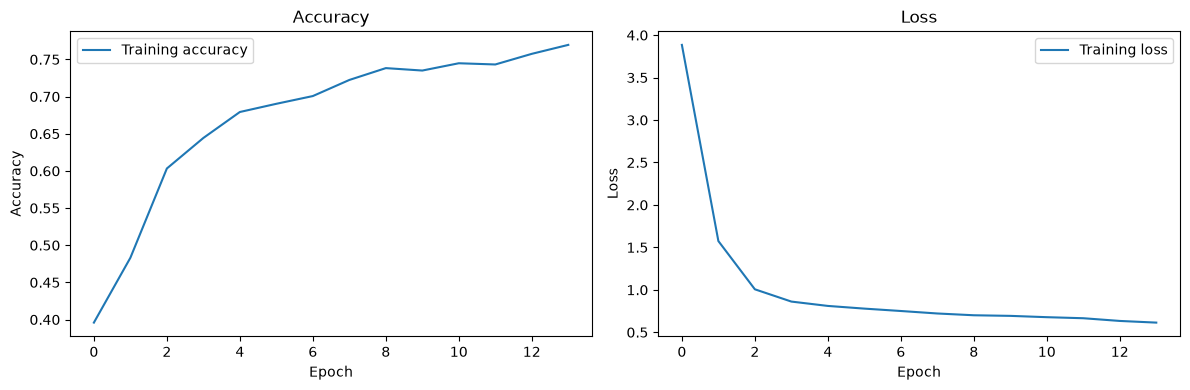

In [9]:
# visualize training accuracy and loss

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(result.history["accuracy"], label="Training accuracy")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(result.history["loss"], label="Training loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
model.evaluate(X_test, y_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7067 - loss: 0.7311


[0.7310640811920166, 0.7066666483879089]

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step


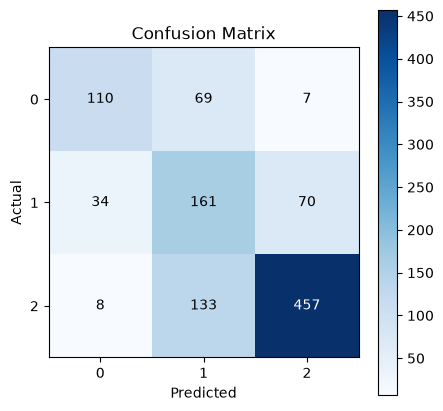

In [11]:
preds = model.predict(X_val)
pred_classes = np.argmax(preds, axis=1)

# build confusion matrix manually, no sklearn needed
cm = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(y_val, pred_classes):
    cm[true][pred] += 1

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.show()

In [13]:
model.save("lstm_review_classifier.keras")